# Initial modeling

This notebook orchestrates the modeling pipeline for the **VentureSurvive** project using the functions defined in `src/`.

In [11]:
# Main imports for the modeling pipeline

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import sys
from pathlib import Path

# Add the project root to the Python path
project_root = Path("..").resolve()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

print("Project root added:", project_root)


from src import data as data_mod
from src import features as features_mod
from src import split as split_mod
from src import model as model_mod
from src import evaluate as eval_mod

import importlib
from src import data as data_mod

importlib.reload(data_mod)  # loading the file src/data.py
print("DATA_PATH_DEFAULT reloaded =", data_mod.DATA_PATH_DEFAULT)


Project root added: /Users/yusefbag/CascadeProjects/venturesurvive
DATA_PATH_DEFAULT reloaded = /Users/yusefbag/CascadeProjects/venturesurvive/data/startups_raw.csv


## Data loading and preparation

In this section, we load the raw data and apply the first cleaning steps: status filtering, label creation, date conversion, and funding amount cleaning.

In [12]:
# Loading raw data
# Load the raw data via the utility function from the data module

df_raw = data_mod.load_raw()
print("df_raw.shape:", df_raw.shape)

# Filtering statuses
df_filtered = data_mod.filter_status(df_raw)
print("df_filtered.shape (after status filtering):", df_filtered.shape)

# Creating the binary success label
df_labeled = data_mod.create_label(df_filtered)

# Converting dates
df_dates = data_mod.convert_dates(df_labeled)

# Cleaning the funding_total_usd column
df_clean = data_mod.clean_funding(df_dates)

print("df_clean.shape (after cleaning):", df_clean.shape)

df_clean.head()

df_raw.shape: (66368, 14)
df_filtered.shape (after status filtering): (13334, 14)
df_clean.shape (after cleaning): (13334, 15)


,permalink,name,homepage_url,category_list,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,founded_at,first_funding_at,last_funding_at,success
15,/organization/1-mainstream,1 Mainstream,http://www.1mainstream.com,Apps|Cable|Distribution|Software,5000000.0,acquired,USA,CA,SF Bay Area,Cupertino,1,2012-03-01,2015-03-17,2015-03-17,1
20,/organization/1000-markets,1000 Markets,http://www.1000markets.com,Art|E-Commerce|Marketplaces,500000.0,acquired,USA,WA,Seattle,Seattle,1,2009-01-01,2009-05-15,2009-05-15,1
23,/organization/1000memories,1000memories,http://1000memories.com,Curated Web,2535000.0,acquired,USA,CA,SF Bay Area,San Francisco,2,2010-07-01,2010-01-01,2011-02-16,1
31,/organization/100plus,100Plus,http://www.100plus.com,Analytics,1250000.0,acquired,USA,CA,SF Bay Area,San Francisco,2,2011-09-16,2011-11-02,2011-11-30,1
32,/organization/1010data,1010data,http://www.1010data.com,Software,35000000.0,acquired,USA,NY,New York City,New York,1,2000-01-01,2010-03-08,2010-03-08,1


In [13]:
# Saving cleaned dataset for reuse

processed_dir = project_root / "data" / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)
clean_path = processed_dir / "startups_clean.csv"

df_clean.to_csv(clean_path, index=False)
print("Cleaned dataset saved to:", clean_path)

Cleaned dataset saved to: /Users/yusefbag/CascadeProjects/venturesurvive/data/processed/startups_clean.csv


## Feature construction

In this section, we build time-based, geographic, and category features, then assemble a feature DataFrame ready for modeling.

In [14]:
# Assembling features from the cleaned DataFrame

# Build the full feature set
df_features = features_mod.assemble_features(df_clean)

# Clean separation of target and features
y = df_features["success"].astype(int)
X_full = df_features.drop(columns=["success"])

# Keep only numeric and boolean columns for the model
X_numeric = X_full.select_dtypes(include=["number", "bool"]).copy()

# Convert boolean columns to float for scikit-learn compatibility
bool_cols = X_numeric.select_dtypes(include=["bool"]).columns
if len(bool_cols) > 0:
    X_numeric[bool_cols] = X_numeric[bool_cols].astype(float)

numeric_feature_names = list(X_numeric.columns)

print("df_features.shape:", df_features.shape)
print("Total number of features (excluding target):", X_full.shape[1])
print("Number of numeric/boolean features used:", len(numeric_feature_names))
print("Target distribution (success):\n", y.value_counts())

X_numeric.head()

df_features.shape: (13334, 22)
Total number of features (excluding target): 21
Number of numeric/boolean features used: 12
Target distribution (success):
 success
1    7096
0    6238
Name: count, dtype: int64


,funding_total_usd,funding_rounds,age_at_first_funding,time_between_first_last,is_us,is_uk,is_eu,country_code_missing,state_code_missing,region_missing,city_missing,log_funding_total
15,5000000.0,1,1111.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,15.424949
20,500000.0,1,134.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,13.122365
23,2535000.0,2,-181.0,411.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,14.745705
31,1250000.0,2,47.0,28.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,14.038655
32,35000000.0,1,3719.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,17.370859


## Train / test split

In this section, we perform a temporal train/test split based on `first_funding_at`, then optionally scale numeric features.

In [15]:
# Temporal train/test split using numeric features only

# Keep the full df_features to have date columns available for the temporal split
df_for_split = df_features.copy()

# Temporal split using the utility function
train_df, test_df = split_mod.temporal_split(
    df_for_split, cutoff_date="2013-01-01", date_col="first_funding_at"
)

print("train_df.shape:", train_df.shape)
print("test_df.shape:", test_df.shape)

# Split X / y using only numeric/boolean columns
feature_cols = numeric_feature_names

y_train = train_df["success"].astype(int)
y_test = test_df["success"].astype(int)

X_train = train_df[feature_cols].copy()
X_test = test_df[feature_cols].copy()

# Explicitly convert any remaining boolean columns to float (safety)
bool_cols_train = X_train.select_dtypes(include=["bool"]).columns
if len(bool_cols_train) > 0:
    X_train[bool_cols_train] = X_train[bool_cols_train].astype(float)
    X_test[bool_cols_train] = X_test[bool_cols_train].astype(float)

print("X_train shape (before imputation):", X_train.shape)
print("X_test shape (before imputation):", X_test.shape)
print("Number of features used:", len(feature_cols))

train_df.shape: (10688, 22)
test_df.shape: (2646, 22)
X_train shape (before imputation): (10688, 12)
X_test shape (before imputation): (2646, 12)
Number of features used: 12


## Handling missing values (NaN imputation)

In this section, we handle NaN values in the numeric features using median imputation before training models.

In [16]:
# Impute missing values using median strategy

from sklearn.impute import SimpleImputer

# Check for NaN before imputation
print("NaN counts in X_train before imputation:")
print(X_train.isna().sum())

# Create imputer and fit on training data
imputer = SimpleImputer(strategy="median")
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

print("\nNaN counts after imputation (should be 0):")
print("X_train:", pd.DataFrame(X_train_imputed).isna().sum().sum())
print("X_test:", pd.DataFrame(X_test_imputed).isna().sum().sum())

# Scale numeric features after imputation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

print("\nX_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

NaN counts in X_train before imputation:
funding_total_usd          1549
funding_rounds                0
age_at_first_funding       2921
time_between_first_last       0
is_us                         0
is_uk                         0
is_eu                         0
country_code_missing          0
state_code_missing            0
region_missing                0
city_missing                  0
log_funding_total          1549
dtype: int64

NaN counts after imputation (should be 0):
X_train: 0
X_test: 0

X_train_scaled shape: (10688, 12)
X_test_scaled shape: (2646, 12)


## Model training

In this section, we train baseline models (Logistic Regression and Random Forest) on the imputed and scaled features.

In [17]:
# Logistic Regression training and evaluation

from sklearn.metrics import brier_score_loss

# Train baseline logistic regression model on scaled numeric features
logistic_model = model_mod.train_logistic(X_train_scaled, y_train.values)

# Standard classification metrics (including ROC AUC when available)
logistic_results = eval_mod.evaluate_classification(
    logistic_model, X_test_scaled, y_test.values
)

# Compute Brier score using predicted probabilities when available
if hasattr(logistic_model, "predict_proba"):
    y_prob = logistic_model.predict_proba(X_test_scaled)[:, 1]
    logistic_brier = brier_score_loss(y_test.values, y_prob)
else:
    logistic_brier = float("nan")

logistic_metrics = {
    "accuracy": float(logistic_results.get("accuracy", float("nan"))),
    "precision": float(logistic_results.get("precision", float("nan"))),
    "recall": float(logistic_results.get("recall", float("nan"))),
    "f1": float(logistic_results.get("f1", float("nan"))),
    "roc_auc": float(logistic_results.get("roc_auc", float("nan"))),
    "brier": float(logistic_brier),
}

print("=== Logistic Regression Results ===")
for metric, value in logistic_metrics.items():
    print(f"{metric}: {value:.4f}")

=== Logistic Regression Results ===
accuracy: 0.7691
precision: 0.6467
recall: 0.6910
f1: 0.6681
roc_auc: 0.8544
brier: 0.1507


In [10]:
# Random Forest training and evaluation

# Train Random Forest model on scaled numeric features
rf_model = model_mod.train_random_forest(X_train_scaled, y_train.values)

# Standard classification metrics
rf_results = eval_mod.evaluate_classification(
    rf_model, X_test_scaled, y_test.values
)

# Compute Brier score
if hasattr(rf_model, "predict_proba"):
    y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]
    rf_brier = brier_score_loss(y_test.values, y_prob_rf)
else:
    rf_brier = float("nan")

rf_metrics = {
    "accuracy": float(rf_results.get("accuracy", float("nan"))),
    "precision": float(rf_results.get("precision", float("nan"))),
    "recall": float(rf_results.get("recall", float("nan"))),
    "f1": float(rf_results.get("f1", float("nan"))),
    "roc_auc": float(rf_results.get("roc_auc", float("nan"))),
    "brier": float(rf_brier),
}

print("=== Random Forest Results ===")
for metric, value in rf_metrics.items():
    print(f"{metric}: {value:.4f}")

=== Random Forest Results ===
accuracy: 0.7426
precision: 0.6085
recall: 0.6584
f1: 0.6325
roc_auc: 0.7966
brier: 0.1758


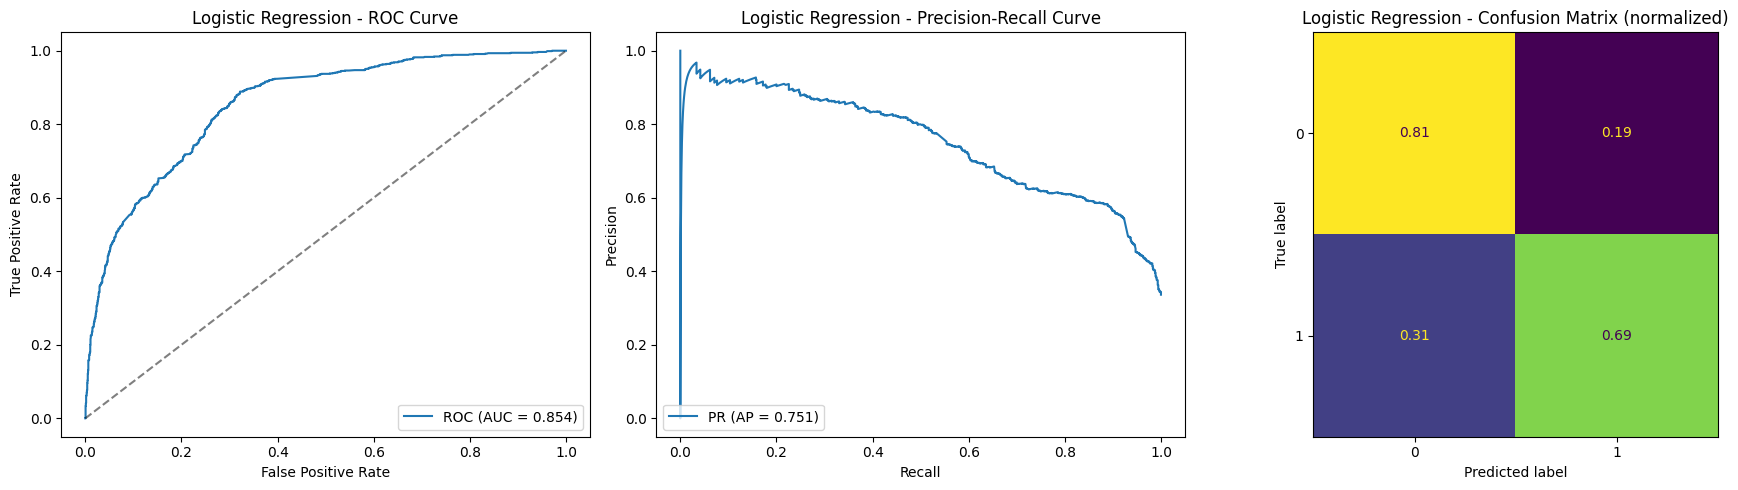

In [18]:
# Visualizations for Logistic Regression

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

eval_mod.plot_roc(logistic_model, X_test_scaled, y_test.values, ax=axes[0])
axes[0].set_title("Logistic Regression - ROC Curve")

eval_mod.plot_pr(logistic_model, X_test_scaled, y_test.values, ax=axes[1])
axes[1].set_title("Logistic Regression - Precision-Recall Curve")

eval_mod.plot_confusion(logistic_model, X_test_scaled, y_test.values, normalize=True, ax=axes[2])
axes[2].set_title("Logistic Regression - Confusion Matrix (normalized)")

plt.tight_layout()
plt.show()

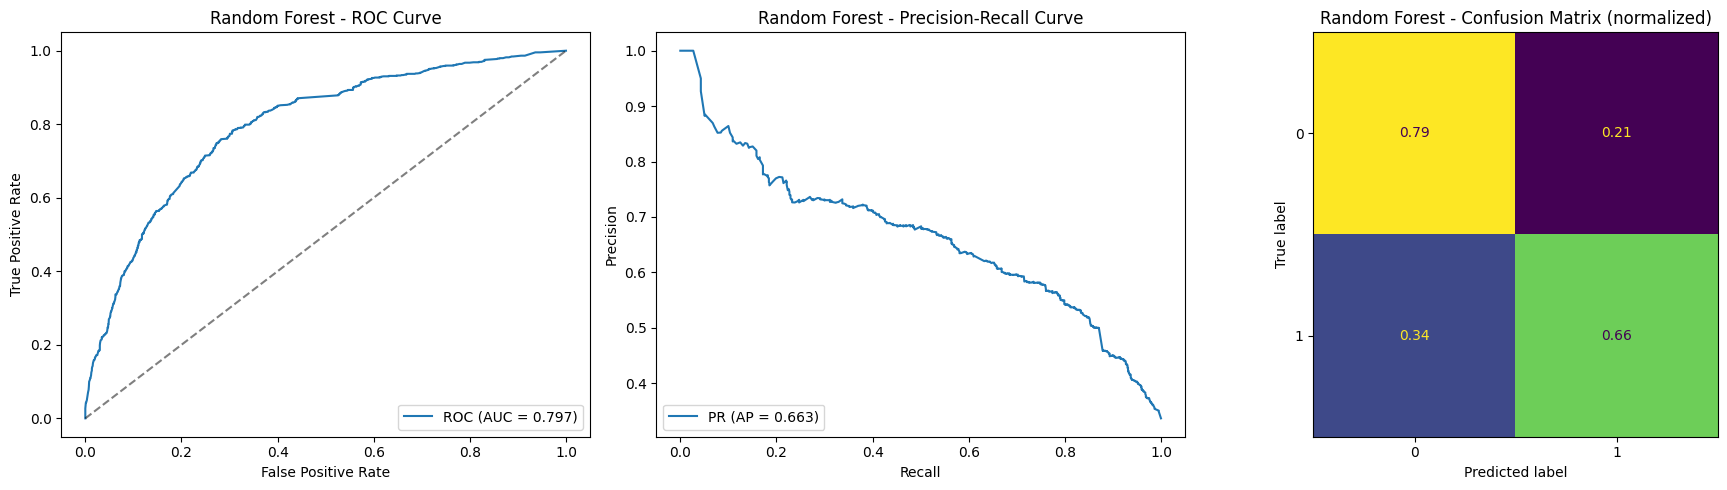

In [19]:
# Visualizations for Random Forest

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

eval_mod.plot_roc(rf_model, X_test_scaled, y_test.values, ax=axes[0])
axes[0].set_title("Random Forest - ROC Curve")

eval_mod.plot_pr(rf_model, X_test_scaled, y_test.values, ax=axes[1])
axes[1].set_title("Random Forest - Precision-Recall Curve")

eval_mod.plot_confusion(rf_model, X_test_scaled, y_test.values, normalize=True, ax=axes[2])
axes[2].set_title("Random Forest - Confusion Matrix (normalized)")

plt.tight_layout()
plt.show()

## Final summary

This section provides a comprehensive summary of the modeling pipeline results.

In [20]:
# Final summary of the modeling pipeline

summary = {
    "dataset": {
        "clean_data_path": str(clean_path),
        "train_shape": train_df.shape,
        "test_shape": test_df.shape,
        "n_features": len(numeric_feature_names),
        "features": numeric_feature_names,
    },
    "logistic_regression": logistic_metrics,
    "random_forest": rf_metrics,
}

print("=" * 60)
print("MODELING PIPELINE SUMMARY")
print("=" * 60)

print("\n### Dataset Information ###")
print(f"Clean data saved at: {summary['dataset']['clean_data_path']}")
print(f"Train set shape: {summary['dataset']['train_shape']}")
print(f"Test set shape: {summary['dataset']['test_shape']}")
print(f"Number of features: {summary['dataset']['n_features']}")

print("\n### Features Used ###")
for i, feat in enumerate(summary['dataset']['features'], 1):
    print(f"  {i}. {feat}")

print("\n### Logistic Regression Performance ###")
for metric, value in summary['logistic_regression'].items():
    print(f"  {metric}: {value:.4f}")

print("\n### Random Forest Performance ###")
for metric, value in summary['random_forest'].items():
    print(f"  {metric}: {value:.4f}")

print("\n### Model Comparison ###")
print(f"Best ROC AUC: {'Random Forest' if rf_metrics['roc_auc'] > logistic_metrics['roc_auc'] else 'Logistic Regression'} "
      f"({max(rf_metrics['roc_auc'], logistic_metrics['roc_auc']):.4f})")
print(f"Best Accuracy: {'Random Forest' if rf_metrics['accuracy'] > logistic_metrics['accuracy'] else 'Logistic Regression'} "
      f"({max(rf_metrics['accuracy'], logistic_metrics['accuracy']):.4f})")

print("\n" + "=" * 60)
print("Next steps:")
print("- Consider encoding categorical variables (one-hot, target encoding)")
print("- Perform hyperparameter tuning (GridSearchCV, RandomizedSearchCV)")
print("- Add feature importance analysis")
print("- Try ensemble methods (XGBoost, LightGBM)")
print("=" * 60)

MODELING PIPELINE SUMMARY

### Dataset Information ###
Clean data saved at: /Users/yusefbag/CascadeProjects/venturesurvive/data/processed/startups_clean.csv
Train set shape: (10688, 22)
Test set shape: (2646, 22)
Number of features: 12

### Features Used ###
  1. funding_total_usd
  2. funding_rounds
  3. age_at_first_funding
  4. time_between_first_last
  5. is_us
  6. is_uk
  7. is_eu
  8. country_code_missing
  9. state_code_missing
  10. region_missing
  11. city_missing
  12. log_funding_total

### Logistic Regression Performance ###
  accuracy: 0.7691
  precision: 0.6467
  recall: 0.6910
  f1: 0.6681
  roc_auc: 0.8544
  brier: 0.1507

### Random Forest Performance ###
  accuracy: 0.7426
  precision: 0.6085
  recall: 0.6584
  f1: 0.6325
  roc_auc: 0.7966
  brier: 0.1758

### Model Comparison ###
Best ROC AUC: Logistic Regression (0.8544)
Best Accuracy: Logistic Regression (0.7691)

Next steps:
- Consider encoding categorical variables (one-hot, target encoding)
- Perform hyperpara